In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation
import numpy as np
import os
import re
import warnings
from numba.core.errors import NumbaDeprecationWarning
import urllib.request
from pathlib import Path
import celltypist
from celltypist import models
from scipy.sparse import csr_matrix

/rds/general/user/ztb25/home/miniforge3/envs/m10/lib/python3.11/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [2]:
sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)

In [3]:
# import preprocessed dataset

dir = "/rds/general/user/ztb25/home/PBMC_datasets/4/PBMC4_preprocessed.h5ad"

adata = sc.read(dir)

In [4]:
adata

AnnData object with n_obs × n_vars = 295440 × 33234
    obs: 'sample', 'fastq_1', 'fastq_2', 'gsm_id', 'sample_num', 'diagnosis', 'age', 'gender', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'gene_symbols', 'feature_types', 'genome', 'gene_versions', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'sample_colors', 'scrublet'
    layers: 'log1p_norm'

In [5]:
# save raw counts first
adata.layers["counts"] = adata.X.copy()

# then set normalised as active layer for PCA
adata.X = adata.layers["log1p_norm"]

In [6]:
# reset sample number order (so its not in lex order)
sample_order = [str(i) for i in range(1, 51)]
adata.obs["sample"] = adata.obs["sample"].cat.set_categories(sample_order, ordered=False)

In [7]:
# compute PCA
sc.pp.pca(
    adata, svd_solver="arpack", use_highly_variable=True)

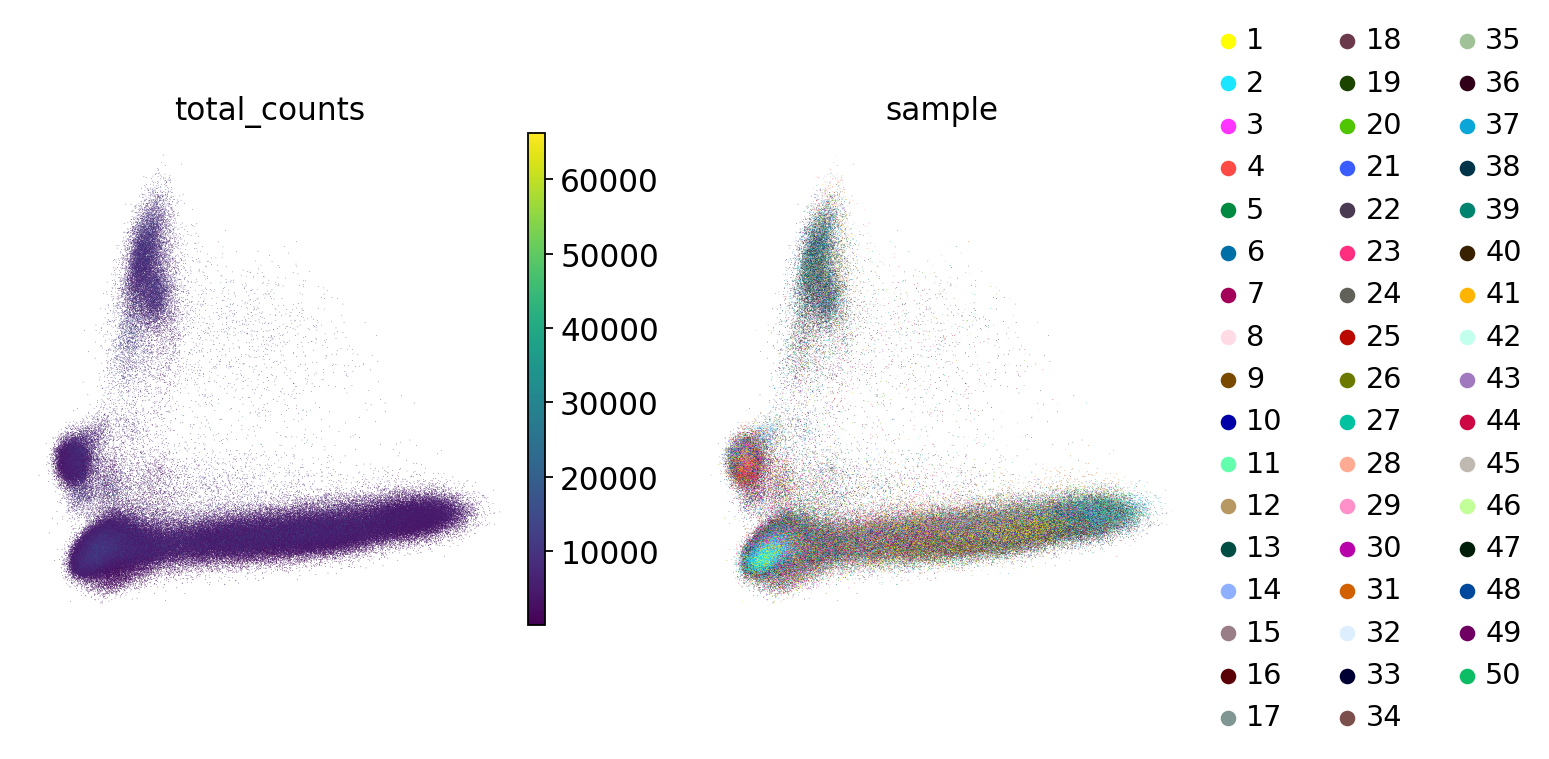

In [8]:
# plot PCA
sc.pl.pca_scatter(adata, color= ["total_counts", "sample"])
# color by total counts and sample to check for batch effects

In [9]:
sc.settings.verbosity = 0
sc.settings.set_figure_params(dpi=80, facecolor="white", frameon=False)

In [10]:
# build neighbour graph (used for leiden clustering and UMAP) 
sc.pp.neighbors(adata)

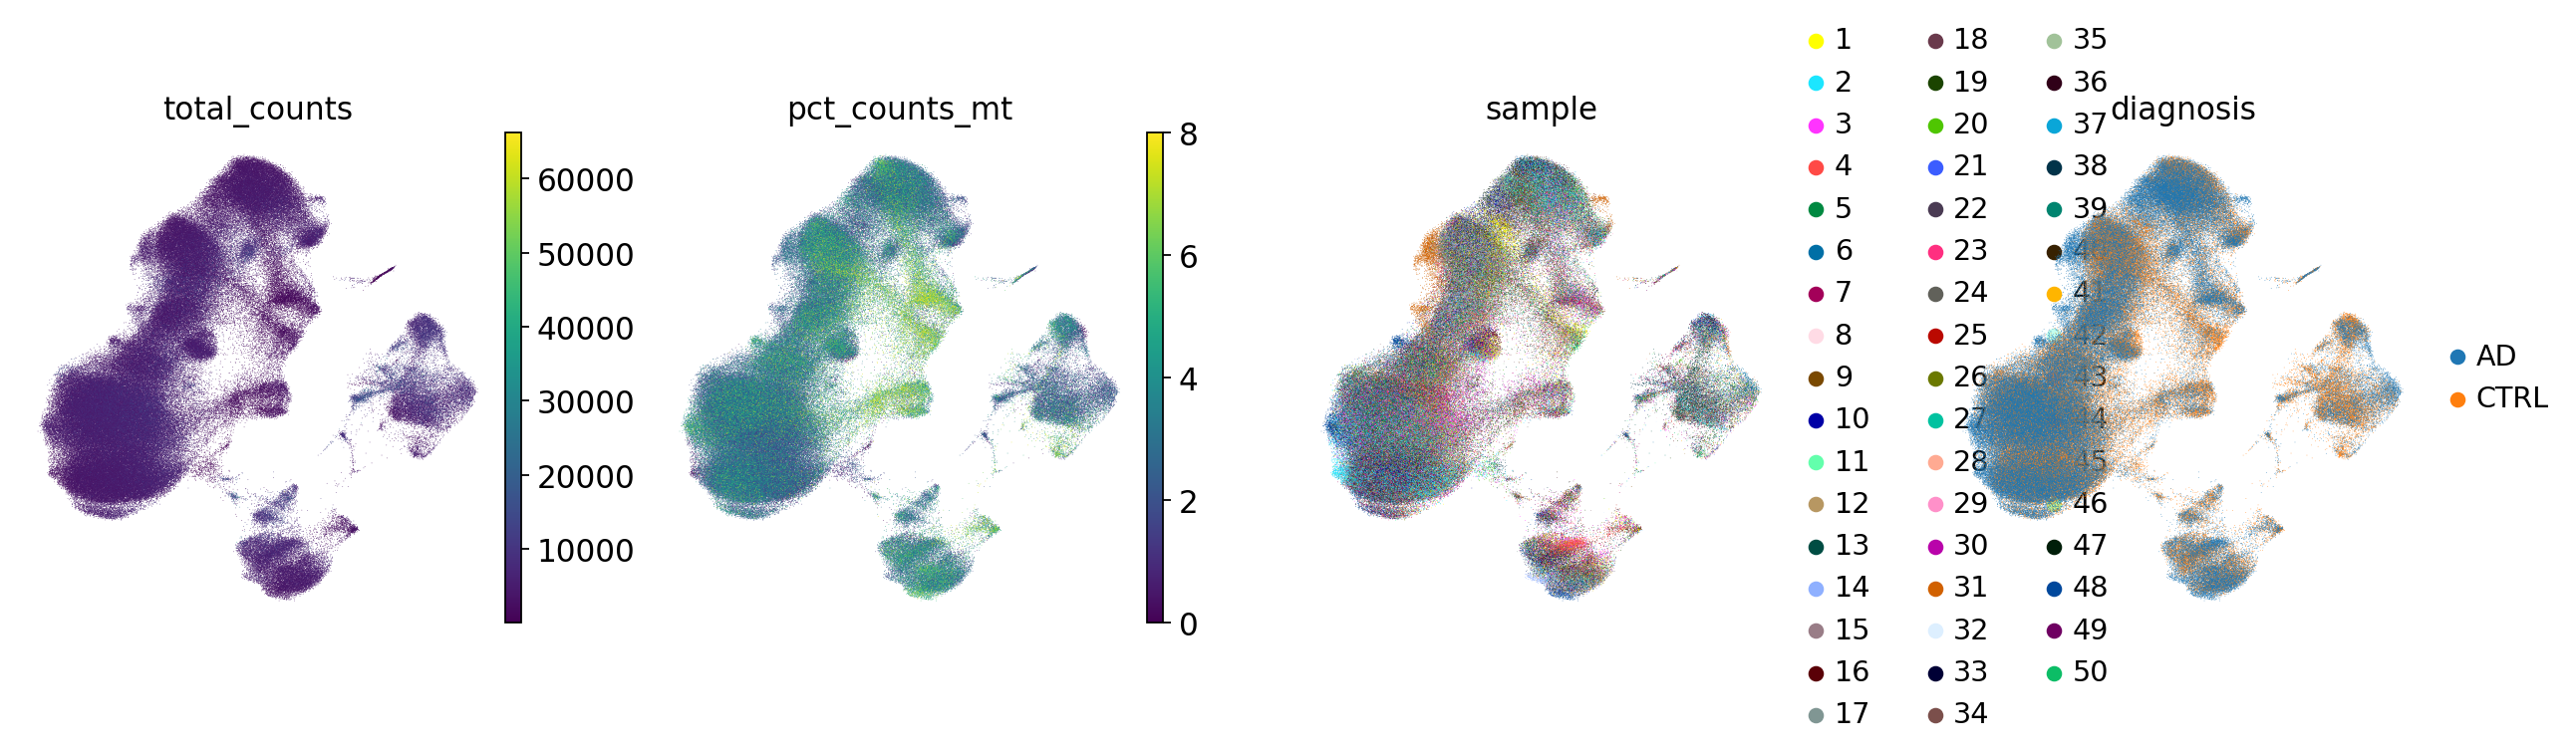

In [11]:
# compute UMAP
sc.tl.umap(adata)

# plot UMAP to check quality control metrics, i.e. see if cells are clustering by non-biological factors
sc.pl.umap(
    adata,
    color=["total_counts", "pct_counts_mt", "sample", "diagnosis"]
)

# no batch correction needed

In [12]:
## Decided to go with celltypist for all datasets, so commetning out manual annotation code for faster running

In [13]:
# # Cluster the data using Leiden clustering (trying different resolutions for finer/coarser clustering)

# sc.tl.leiden(adata, key_added="leiden_res0_25", resolution=0.25)
# sc.tl.leiden(adata, key_added="leiden_res0_5", resolution=0.5)
# sc.tl.leiden(adata, key_added="leiden_res1", resolution=1.0)
# sc.tl.leiden(adata, key_added="leiden_res2", resolution=2)

In [14]:
# sc.pl.umap(
#     adata,
#     color=["leiden_res0_25", "leiden_res0_5", "leiden_res1", "leiden_res2"],
#     legend_loc="on data",
#     # size = 4,
#     # legend_fontsize=10,

# )

In [15]:
# # setup for annotation
# warnings.filterwarnings("ignore", category=DeprecationWarning)
# warnings.simplefilter("ignore", category=NumbaDeprecationWarning)
# warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

# sc.set_figure_params(figsize=(5, 5))

In [16]:
# # list of marker genes for different cell types (from sc-best practices)
# marker_genes = {
#     "CD14+ Mono": ["FCN1", "CD14"],
#     "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
#     "ID2-hi myeloid prog": [
#         "CD14",
#         "ID2",
#         "VCAN",
#         "S100A9",
#         "CLEC12A",
#         "KLF4",
#         "PLAUR",
#     ],
#     "cDC1": ["CLEC9A", "CADM1"],
#     "cDC2": [
#         "CST3",
#         "COTL1",
#         "LYZ",
#         "DMXL2",
#         "CLEC10A",
#         "FCER1A",
#     ],  # Note: DMXL2 should be negative
#     "Normoblast": ["SLC4A1", "SLC25A37", "HBB", "HBA2", "HBA1", "TFRC"],
#     "Erythroblast": ["MKI67", "HBA1", "HBB"],
#     "Proerythroblast": [
#         "CDK6",
#         "SYNGR1",
#         "HBM",
#         "GYPA",
#     ],  # Note HBM and GYPA are negative markers
#     "NK": ["GNLY", "NKG7", "CD247", "GRIK4", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
#     "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
#     "Lymph prog": [
#         "VPREB1",
#         "MME",
#         "EBF1",
#         "SSBP2",
#         "BACH2",
#         "CD79B",
#         "IGHM",
#         "PAX5",
#         "PRKCE",
#         "DNTT",
#         "IGLL1",
#     ],
#     "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
#     "B1 B": [
#         "MS4A1",
#         "SSPN",
#         "ITGB1",
#         "EPHA4",
#         "COL4A4",
#         "PRDM1",
#         "IRF4",
#         "CD38",
#         "XBP1",
#         "PAX5",
#         "BCL11A",
#         "BLK",
#         "IGHD",
#         "IGHM",
#         "ZNF215",
#     ],  # Note IGHD and IGHM are negative markers
#      "B cells": [
#         "MS4A1",
#         "ITGB1",
#         "COL4A4",
#         "PRDM1",
#         "IRF4",
#         "PAX5",
#         "BCL11A",
#         "BLK",
#         "IGHD",
#         "IGHM",
#     ], # from scanpy (broader)
#     "Transitional B": ["MME", "CD38", "CD24", "ACSM3", "MSI2"],
#     "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
#     "Plasmablast": ["XBP1", "RF4", "PRDM1", "PAX5"],  # Note PAX5 is a negative marker
#     "CD4+ T": ["CD4", "IL7R", "TRBC2"], # from scanpy (broader)
#     "CD4+ T activated": ["CD4", "IL7R", "TRBC2", "ITGB1"],
#     "CD4+ T naive": ["CD4", "IL7R", "TRBC2", "CCR7"],
#     "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
#     "T activation": ["CD69", "CD38"],  # CD69 much better marker!
#     "T naive": ["LEF1", "CCR7", "TCF7"],
#     "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
#     "G/M prog": ["MPO", "BCL2", "KCNQ5", "CSF3R"],
#     "HSC": ["NRIP1", "MECOM", "PROM1", "NKAIN2", "CD34"],
#     "MK/E prog": [
#         "ZNF385D",
#         "ITGA2B",
#         "RYR3",
#         "PLCB1",
#     ],  # Note PLCB1 is a negative marker
# }


In [17]:
# # Subset to only the markers that were detected in our data
# marker_genes_in_data = {}
# for ct, markers in marker_genes.items():
#     markers_found = []
#     for marker in markers:
#         if marker in adata.var.index:
#             markers_found.append(marker)
#     marker_genes_in_data[ct] = markers_found

# print(f"The data contains {len(marker_genes_in_data)} out of {len(marker_genes)} cell type marker genes")

In [18]:
# # show expression of markers using UMAP (first only looking at broad cell types)

# broad_cts = [
#     "B cells", 
#     "Plasma cells",
#     "CD4+ T",   
#     "CD8+ T",
#     "T naive",
#     "NK",
#     "CD14+ Mono",
#     "CD16+ Mono",
#     "cDC2",           # representative DC
#     "pDC",
# ]

In [19]:
# # make gene symbols your var index (currently its ensembl IDs, breaking followig plots)

# adata.var.index = adata.var["gene_symbols"].fillna(adata.var["ensembl_ids"]).astype(str)
# adata.var_names_make_unique()

In [20]:
# # plot on UMAP per marker for each of the cell types (IOW, looking at expression of each marker for each subtype)

# for ct in broad_cts:
#     print(f"{ct.upper()}:")  # print cell subtype name
#     sc.pl.umap(
#         adata,
#         color=marker_genes_in_data[ct],
#         vmin=0,
#         vmax="p99",  # set vmax to the 99th percentile of the gene count instead of the maximum, to prevent outliers from making expression in other cells invisible. Note that this can cause problems for extremely lowly expressed genes.
#         sort_order=False,  # do not plot highest expression on top, to not get a biased view of the mean expression among cells
#         frameon=False,
#         cmap="Reds",  # or choose another color map e.g. from here: https://matplotlib.org/stable/tutorials/colors/colormaps.html
#     )
#     print("\n\n\n")  # print white space for legibility

In [21]:
# # visualise using dotplot

# broad_cts_markers = {
#     ct: [m for m in ct_markers if m in adata.var.index]
#     for ct, ct_markers in marker_genes.items()
#     if ct in broad_cts
# }

In [22]:
# sc.pl.dotplot(
#     adata,
#     groupby="leiden_res0_25",   # rows = leiden clusters 
#     var_names=broad_cts_markers,  # columns = list of broad ct marker genes
#     standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1 (so genes with different expression scales are comparable)
# )

# # Size of dot   → fraction of cells in that cluster expressing the gene (bigger = more cells express it)
# # Colour of dot → expression level (scaled 0-1 per gene) (darker = higher expression)

In [23]:
# # not too clear, trying the other way round (calculate marker genes per cluster first (using Wilcoxon rank-sum test)

# # first at res 0.25
# sc.tl.rank_genes_groups(
#     adata, groupby="leiden_res0_25", method="wilcoxon", key_added="dea_leiden_0_25"
# )

# # visusalise expression of top DEGs per cluster with dotplot

# sc.pl.rank_genes_groups_dotplot(
#     adata, groupby="leiden_res0_25", standard_scale="var", n_genes=5, key="dea_leiden_0_25"
# )


In [24]:
# # filter the DEGs to select for more cluster-specific DEGs

# sc.tl.filter_rank_genes_groups(
#     adata,
#     min_in_group_fraction=0.2,
#     max_out_group_fraction=0.2,
#     key="dea_leiden_0_25",
#     key_added="dea_leiden_0_25_filtered",
# )

In [25]:
# # visualise filtered genes

# sc.pl.rank_genes_groups_dotplot(
#     adata,
#     groupby="leiden_res0_25",
#     standard_scale="var",
#     n_genes=5,
#     key="dea_leiden_0_25_filtered",
# )

# # PLCB1, PAX5, IGHD, IGHM, HBM, GYPA, DMXL2 --> negative markers

In [26]:
# CellTypist

# first prepare data to format needed for cellTypist (nromalised to 10,000 counts per cell then log1p transformed)

adata_celltypist = adata.copy()  # make a copy of our adata
adata_celltypist.X = adata.layers["counts"]  # set adata.X to raw counts

# Swap var_names to gene symbols so CellTypist's model features can match
adata_celltypist.var_names = adata_celltypist.var["gene_symbols"].astype(str)
adata_celltypist.var_names_make_unique()

sc.pp.normalize_total(
    adata_celltypist, target_sum=10**4
)  # normalize to 10,000 counts per cell
sc.pp.log1p(adata_celltypist)  # log-transform
# make .X dense instead of sparse, for compatibility with celltypist:
adata_celltypist.X = adata_celltypist.X.toarray()


In [27]:
# download celltypist models for immune cells 
models.download_models(
    force_update=True, model=["Immune_All_Low.pkl", "Immune_All_High.pkl"]
)

model_low = models.Model.load(model="Immune_All_Low.pkl") # finer annotation level
model_high = models.Model.load(model="Immune_All_High.pkl") # coarser annotation level

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json


📚 Total models in list: 61


📂 Storing models in /rds/general/user/ztb25/home/.celltypist/data/models


💾 Total models to download: 2


💾 Downloading model [1/2]: Immune_All_Low.pkl


💾 Downloading model [2/2]: Immune_All_High.pkl


In [28]:
# run high model 

predictions_high = celltypist.annotate(
    adata_celltypist, model=model_high, majority_voting=True #?
)

predictions_high_adata = predictions_high.to_adata() # transform predictions to adata for full output

# copy results into original AnnData obj
adata.obs["celltypist_cell_label_coarse"] = predictions_high_adata.obs.loc[
    adata.obs.index, "majority_voting"
]
adata.obs["celltypist_conf_score_coarse"] = predictions_high_adata.obs.loc[
    adata.obs.index, "conf_score"
]

🔬 Input data has 295440 cells and 33234 genes


🔗 Matching reference genes in the model


🧬 5289 features used for prediction


⚖️ Scaling input data


🖋️ Predicting labels


✅ Prediction done!


👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it


⛓️ Over-clustering input data with resolution set to 30


🗳️ Majority voting the predictions


✅ Majority voting done!


In [29]:
# run low model

predictions_low = celltypist.annotate(
    adata_celltypist, model=model_low, majority_voting=True
)

predictions_low_adata = predictions_low.to_adata()

adata.obs["celltypist_cell_label_fine"] = predictions_low_adata.obs.loc[
    adata.obs.index, "majority_voting"
]
adata.obs["celltypist_conf_score_fine"] = predictions_low_adata.obs.loc[
    adata.obs.index, "conf_score"
]

🔬 Input data has 295440 cells and 33234 genes


🔗 Matching reference genes in the model


🧬 5289 features used for prediction


⚖️ Scaling input data


🖋️ Predicting labels


✅ Prediction done!


👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it


⛓️ Over-clustering input data with resolution set to 30


🗳️ Majority voting the predictions


✅ Majority voting done!


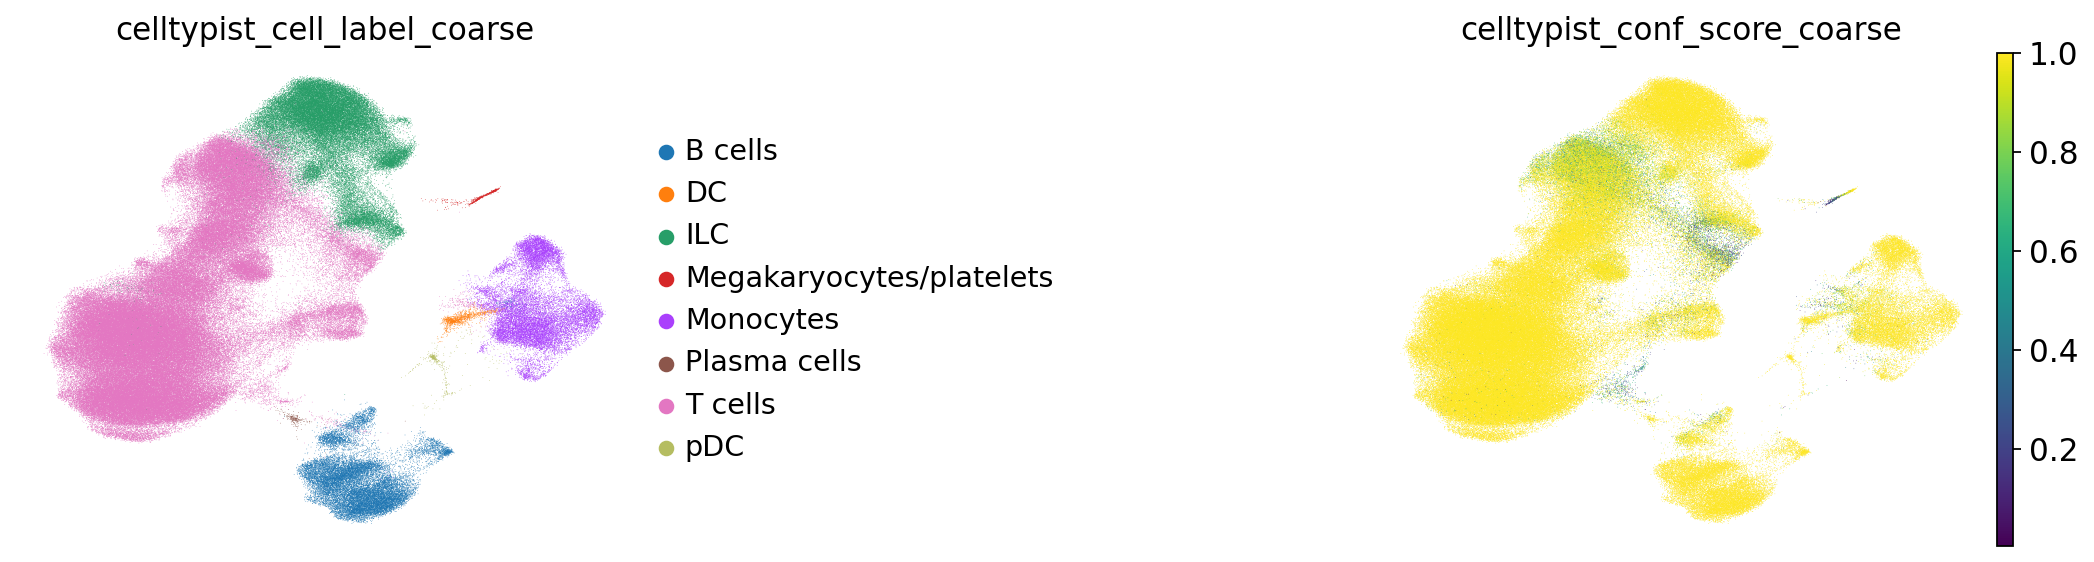

In [30]:
# plot (coarse)

sc.pl.umap(
    adata,
    color=["celltypist_cell_label_coarse", "celltypist_conf_score_coarse"],
    frameon=False,
    sort_order=False,
    wspace=1,
)


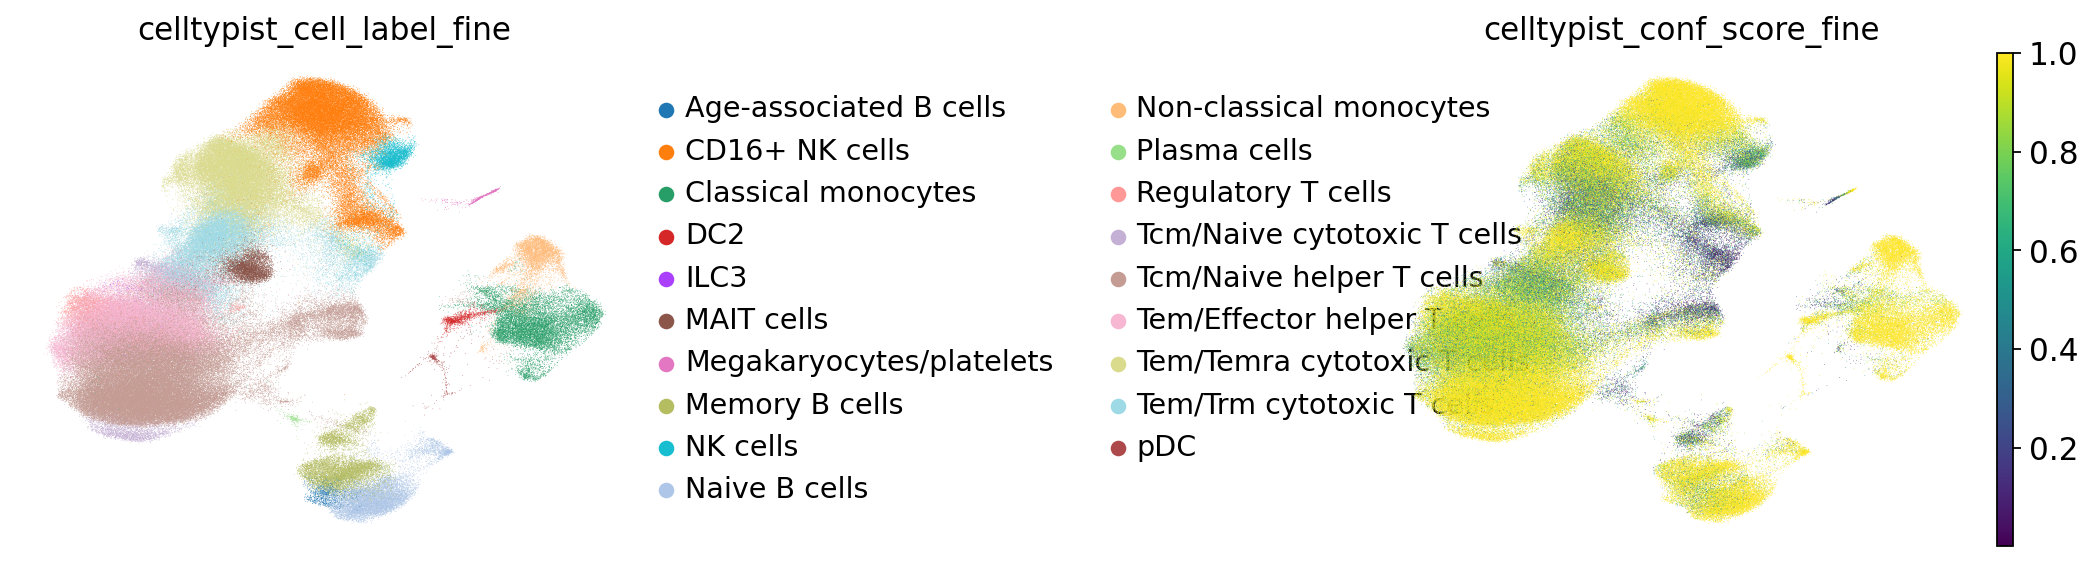

In [31]:
# plot (fine)

sc.pl.umap(
    adata,
    color=["celltypist_cell_label_fine", "celltypist_conf_score_fine"],
    frameon=False,
    sort_order=False,
    wspace=1,
)

In [32]:
# check what is there
[k for k in adata.uns.keys() if "dea" in k or "rank_genes" in k]

[]

In [33]:
# deleting 
for k in ["dea_leiden_0_25_filtered", "dea_leiden_0_25"]:
    if k in adata.uns:
        del adata.uns[k]
        
adata.write("/rds/general/user/ztb25/home/PBMC_datasets/4/PBMC4_clustering.h5ad")